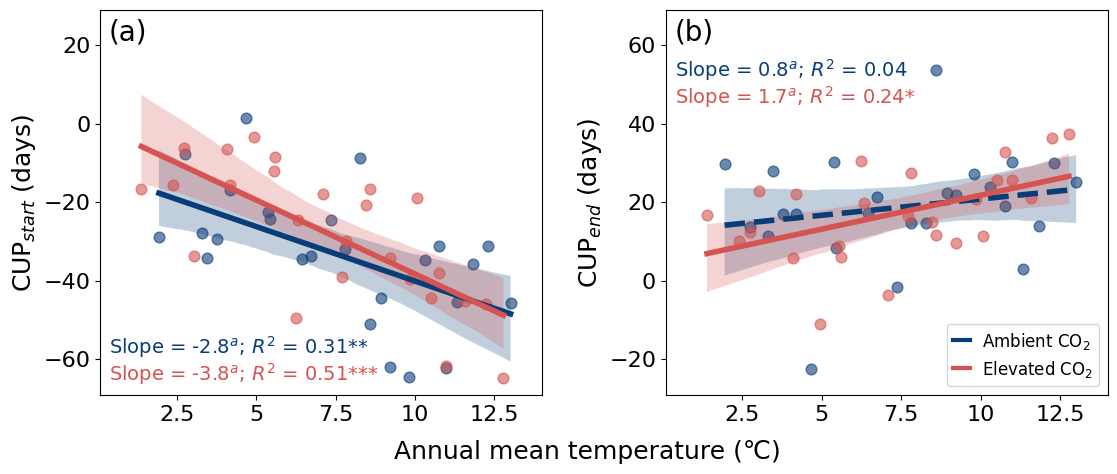

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ============================================================
# 0) Read data
# ============================================================
df = pd.read_excel(
    "../../data_results/2_results/2-3_gppmax_cup_6methods/calculated_GPPmax_CUP_ampFracs_10_20_30_25_thresholdScope_ecosystem.xlsx"
)
df = df[df["year"] > 2016].copy()

# ============================================================
# 1) Slope-difference test: interaction p
#    model: y ~ x + group + x:group
# ============================================================
def cal_reg_diff(x1, y1, x2, y2, alpha=0.05):
    x = np.concatenate([x1, x2])
    y = np.concatenate([y1, y2])

    d = pd.DataFrame({
        "x": x,
        "y": y,
        "group": np.r_[np.repeat(1, len(x1)), np.repeat(2, len(x2))]
    })
    d["group"] = d["group"].astype("category")

    model = smf.ols("y ~ x + C(group) + x:C(group)", data=d).fit()
    term = [n for n in model.pvalues.index if (":" in n) and ("x" in n) and ("C(group)" in n)]
    if len(term) != 1:
        raise KeyError(f"Cannot uniquely identify interaction term. Found: {term}")

    p_int = float(model.pvalues[term[0]])
    return ("a", "b") if p_int < alpha else ("a", "a")

# ============================================================
# 2) Fit linear + style
# ============================================================
def fit_linear(x, y, alpha=0.05):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    X = sm.add_constant(x)
    m = sm.OLS(y, X).fit()

    p_model = float(m.f_pvalue)
    linestyle = "-" if p_model < alpha else "--"
    stars = "***" if p_model < 0.001 else ("**" if p_model < 0.01 else ("*" if p_model < 0.05 else ""))

    b0, b1 = m.params  # const, x
    r2 = float(m.rsquared)

    return {"model": m, "p": p_model, "linestyle": linestyle, "stars": stars, "b0": b0, "b1": b1, "r2": r2}

def fmt_num(v, nd=1, tol=1e-8):
    if (v is None) or (np.isnan(v)) or (abs(float(v)) < tol):
        return "0"
    v = float(v)
    if abs(v) >= 1:
        return f"{v:.{nd}f}".rstrip("0").rstrip(".")
    return f"{v:.1g}"

def eq_text_linear(fit, sup="a", nd_slope=1, nd_r2=2):
    b1s = fmt_num(fit["b1"], nd=nd_slope)
    r2 = fit["r2"]
    r2s = f"{r2:.{nd_r2}f}"
    if r2 > 0.01:
        return f"Slope = {b1s}$^{{{sup}}}$; $R^2$ = {r2s}{fit['stars']}"
    return f"Slope = {b1s}$^{{{sup}}}$; $R^2$ < 0.01"

def draw_reg(ax, x, y, color, linestyle, scatter_alpha=0.6, line_alpha=1.0):
    sns.regplot(
        x=x, y=y, ax=ax,
        order=1,
        scatter_kws={"alpha": scatter_alpha, "color": color, "s": 60},
        line_kws={"linestyle": linestyle, "alpha": line_alpha, "linewidth": 4},
        color=color
    )
    # lighten CI band if exists
    if len(ax.collections) > 1:
        ax.collections[-1].set_alpha(0.25)

# ============================================================
# 3) Plot settings (only 2 variables)
# ============================================================
x_col = "temp_mean_anom"
co2_col = "co2"
aCO2_value = 0
eCO2_value = 500

vars_to_plot = [
    ("cup_start_whsM_25_anom", "CUP$_{start}$ (days)", (-69, 29)),
    ("cup_end_whsM_25_anom",   "CUP$_{end}$ (days)",   (-29, 69)),
]

subtitles = ["(a)", "(b)"]

# text positions in axes coords
text_pos = {
    "cup_start_whsM_25_anom": ((0.02, 0.09), (0.02, 0.02)),
    "cup_end_whsM_25_anom":   ((0.02, 0.81), (0.02, 0.74)),
}

blue = "#093D77"
red  = "#d55350"
x_ticks = [2.5, 5, 7.5, 10, 12.5]

# ============================================================
# 4) Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes = np.atleast_1d(axes)

# group data
d1 = df[df[co2_col] == aCO2_value].copy()
d2 = df[df[co2_col] == eCO2_value].copy()

for i, (var, ylabel, ylims) in enumerate(vars_to_plot):
    ax = axes[i]
    ax.text(0.02, 0.92, subtitles[i], transform=ax.transAxes, fontsize=20)

    ax.set_xlim(0.1, 14)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_ylim(ylims)  # 如果你想固定 y 轴，取消注释

    x1 = d1[x_col].to_numpy(float)
    y1 = d1[var].to_numpy(float)
    x2 = d2[x_col].to_numpy(float)
    y2 = d2[var].to_numpy(float)

    # slope-diff label via interaction p
    sup1, sup2 = cal_reg_diff(x1, y1, x2, y2, alpha=0.05)

    # linear fits
    fit1 = fit_linear(x1, y1, alpha=0.05)
    fit2 = fit_linear(x2, y2, alpha=0.05)

    # draw
    draw_reg(ax, x1, y1, color=blue, linestyle=fit1["linestyle"])
    draw_reg(ax, x2, y2, color=red,  linestyle=fit2["linestyle"])

    # text
    (tx_blue, ty_blue), (tx_red, ty_red) = text_pos[var]
    ax.text(tx_blue, ty_blue, eq_text_linear(fit1, sup=sup1), fontsize=14,
            transform=ax.transAxes, color=blue, va="bottom")
    ax.text(tx_red,  ty_red,  eq_text_linear(fit2, sup=sup2), fontsize=14,
            transform=ax.transAxes, color=red, va="bottom")

    ax.set_ylabel(ylabel, fontsize=18)

# common x label
fig.text(0.5, 0.03, "Annual mean temperature (℃)", fontsize=18, ha="center", va="center")

# legend
import matplotlib.lines as mlines
blue_line = mlines.Line2D([], [], color=blue, linestyle="-", linewidth=3, label="Ambient CO$_2$")
red_line  = mlines.Line2D([], [], color=red,  linestyle="-", linewidth=3, label="Elevated CO$_2$")

axes[1].legend(
    loc="lower right",
    handles=[blue_line, red_line],
    fontsize=12,
    handlelength=1.0,
    handleheight=1.2,
    handletextpad=0.7,
    labelspacing=0.4,
    borderpad=0.4,
)

plt.subplots_adjust(wspace=0.28, bottom=0.14)
plt.show()